Number of full-factorial PDE points: 1000
Relative L2 error: 1.627792e-04
Max absolute error: 3.409386e-04


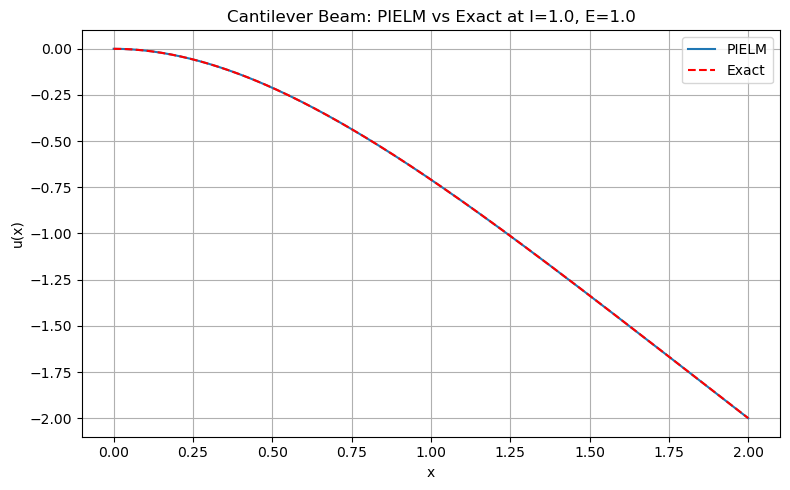

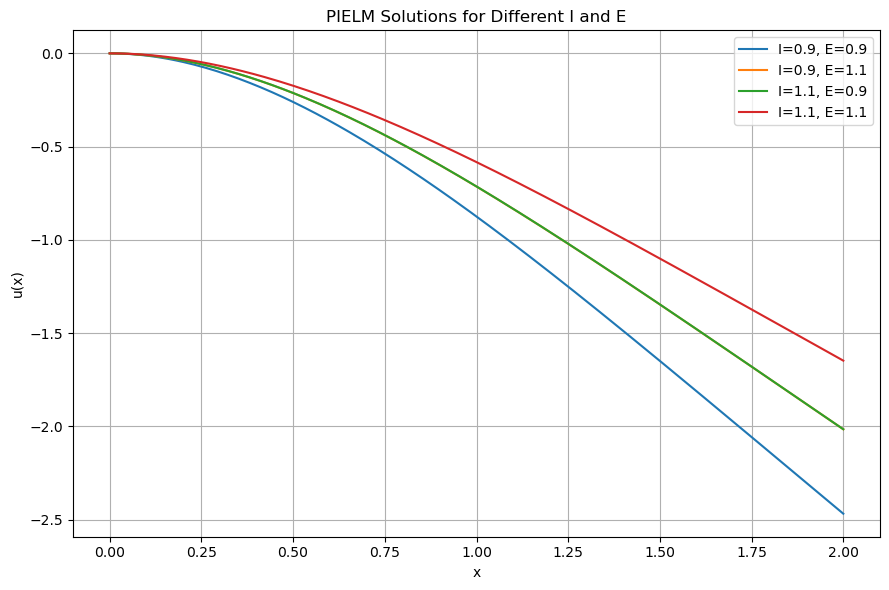

In [1]:
import torch
import torch.autograd as autograd
import numpy as np
import matplotlib.pyplot as plt
from itertools import product

torch.manual_seed(0)
torch.set_default_dtype(torch.float32)

# =========================================================
# Beam problem
# Governing equation:
#     E*I*u_xxxx = q
# Example: cantilever beam with uniform load q
# BCs:
#     u(0)=0, u'(0)=0, u''(L)=0, u'''(L)=0
# =========================================================

L = 2.0
q = -1.0

# Uncertain parameter ranges
I_range = [0.9, 1.1]
E_range = [0.9, 1.1]

# =========================================================
# Exact solution for cantilever beam under uniform load
# u(x) = q*x^2*(6L^2 - 4Lx + x^2)/(24EI)
# =========================================================
def exact_solution(x, I, E):
    return q * x**2 * (6*L**2 - 4*L*x + x**2) / (24 * E * I)

# =========================================================
# Full factorial sampling
# =========================================================
def full_factorial_sampling_3d(n1, n2, n3,
                               range1=(0.0, 1.0),
                               range2=(0.0, 1.0),
                               range3=(0.0, 1.0)):
    a1 = torch.linspace(range1[0], range1[1], n1)
    a2 = torch.linspace(range2[0], range2[1], n2)
    a3 = torch.linspace(range3[0], range3[1], n3)

    pts = list(product(a1, a2, a3))
    return torch.tensor(pts, dtype=torch.float32)

# =========================================================
# ELM setup
# Input = (x, I, E)
# =========================================================
hidden_size = 150
input_dim = 3

W = torch.randn(input_dim, hidden_size)
b = torch.randn(hidden_size)

def hidden_layer(X):
    # Gaussian activation
    return torch.exp(-(X @ W + b)**2)

# =========================================================
# Trial solution
# Use x^2 so that u(0)=0 and u'(0)=0 automatically
# =========================================================
def trial_features(X):
    x = X[:, 0:1]
    return (x**2) * hidden_layer(X)

# =========================================================
# Solve PIELM using full factorial PDE points
# =========================================================
def solve_pielm_full_factorial(
    n_x=10,
    n_I=10,
    n_E=10,
    n_bc_param=10,
    lambda_bc=50.0,
    reg=1e-6
):
    # -----------------------------------------------------
    # PDE collocation points: full factorial in (x, I, E)
    # -----------------------------------------------------
    X_pde = full_factorial_sampling_3d(
        n_x, n_I, n_E,
        range1=(0.0, L),
        range2=(I_range[0], I_range[1]),
        range3=(E_range[0], E_range[1])
    ).requires_grad_(True)

    U = trial_features(X_pde)

    A_cols = []
    for j in range(hidden_size):
        uj = U[:, j:j+1]

        grad1 = autograd.grad(uj.sum(), X_pde, create_graph=True)[0]
        uj_x = grad1[:, 0:1]

        grad2 = autograd.grad(uj_x.sum(), X_pde, create_graph=True)[0]
        uj_xx = grad2[:, 0:1]

        grad3 = autograd.grad(uj_xx.sum(), X_pde, create_graph=True)[0]
        uj_xxx = grad3[:, 0:1]

        grad4 = autograd.grad(uj_xxx.sum(), X_pde, create_graph=True)[0]
        uj_xxxx = grad4[:, 0:1]

        I_vals = X_pde[:, 1:2]
        E_vals = X_pde[:, 2:3]

        # PDE: E*I*u_xxxx = q
        A_cols.append(E_vals * I_vals * uj_xxxx)

    A = torch.hstack(A_cols)
    b_pde = torch.full((X_pde.shape[0], 1), q)

    # -----------------------------------------------------
    # Boundary conditions at x = L:
    # u''(L) = 0, u'''(L) = 0
    # Need parameter sampling only in (I,E)
    # -----------------------------------------------------
    IE_bc = full_factorial_sampling_3d(
        1, n_bc_param, n_bc_param,
        range1=(L, L),
        range2=(I_range[0], I_range[1]),
        range3=(E_range[0], E_range[1])
    ).requires_grad_(True)

    U_bc = trial_features(IE_bc)

    C1_cols = []   # u''(L)=0
    C2_cols = []   # u'''(L)=0

    for j in range(hidden_size):
        uj = U_bc[:, j:j+1]

        grad1 = autograd.grad(uj.sum(), IE_bc, create_graph=True)[0]
        uj_x = grad1[:, 0:1]

        grad2 = autograd.grad(uj_x.sum(), IE_bc, create_graph=True)[0]
        uj_xx = grad2[:, 0:1]

        grad3 = autograd.grad(uj_xx.sum(), IE_bc, create_graph=True)[0]
        uj_xxx = grad3[:, 0:1]

        C1_cols.append(uj_xx)
        C2_cols.append(uj_xxx)

    C1 = torch.hstack(C1_cols)
    C2 = torch.hstack(C2_cols)

    d1 = torch.zeros((IE_bc.shape[0], 1))
    d2 = torch.zeros((IE_bc.shape[0], 1))

    C = torch.vstack([C1, C2])
    d = torch.vstack([d1, d2])

    # -----------------------------------------------------
    # KKT system
    # -----------------------------------------------------
    A_T, C_T = A.T, C.T
    n_constraints = C.shape[0]

    KKT = torch.zeros(hidden_size + n_constraints,
                      hidden_size + n_constraints)

    KKT[:hidden_size, :hidden_size] = A_T @ A + reg * torch.eye(hidden_size)
    KKT[:hidden_size, hidden_size:] = lambda_bc * C_T
    KKT[hidden_size:, :hidden_size] = lambda_bc * C

    rhs = torch.vstack([A_T @ b_pde, lambda_bc * d])

    sol = torch.linalg.solve(KKT, rhs)
    beta = sol[:hidden_size]

    return beta, X_pde

# =========================================================
# Train
# =========================================================
beta, X_train = solve_pielm_full_factorial(
    n_x=10, n_I=10, n_E=10,
    n_bc_param=10,
    lambda_bc=50.0,
    reg=1e-6
)

print("Number of full-factorial PDE points:", X_train.shape[0])  # should be 1000

def predict(X):
    return trial_features(X) @ beta

# =========================================================
# Compare predicted and exact at selected values
# =========================================================
I_test = 1.0
E_test = 1.0

x_plot = torch.linspace(0, L, 200).reshape(-1, 1)
I_plot = torch.full_like(x_plot, I_test)
E_plot = torch.full_like(x_plot, E_test)

X_test = torch.cat([x_plot, I_plot, E_plot], dim=1)

u_pred = predict(X_test).detach().squeeze()
u_exact = exact_solution(x_plot, I_plot, E_plot).detach().squeeze()

rel_l2_error = torch.norm(u_pred - u_exact) / torch.norm(u_exact)
max_abs_error = torch.max(torch.abs(u_pred - u_exact))

print(f"Relative L2 error: {rel_l2_error.item():.6e}")
print(f"Max absolute error: {max_abs_error.item():.6e}")

# =========================================================
# Plot comparison
# =========================================================
plt.figure(figsize=(8, 5))
plt.plot(x_plot.numpy(), u_pred.numpy(), label="PIELM")
plt.plot(x_plot.numpy(), u_exact.numpy(), "r--", label="Exact")
plt.xlabel("x")
plt.ylabel("u(x)")
plt.title(f"Cantilever Beam: PIELM vs Exact at I={I_test}, E={E_test}")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# =========================================================
# Optional: compare displacement variation for different I,E
# =========================================================
cases = [
    (0.9, 0.9),
    (0.9, 1.1),
    (1.1, 0.9),
    (1.1, 1.1),
]

plt.figure(figsize=(9, 6))
for I_case, E_case in cases:
    I_case_vec = torch.full_like(x_plot, I_case)
    E_case_vec = torch.full_like(x_plot, E_case)
    X_case = torch.cat([x_plot, I_case_vec, E_case_vec], dim=1)
    u_case = predict(X_case).detach().squeeze()
    plt.plot(x_plot.numpy(), u_case.numpy(), label=f"I={I_case}, E={E_case}")

plt.xlabel("x")
plt.ylabel("u(x)")
plt.title("PIELM Solutions for Different I and E")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

Number of full-factorial PDE points: 1000
Relative L2 error: 1.702822e-02
Max absolute error: 2.152443e-03

ECDF Summary for Absolute Error
P(|error| <= 1.0e-06) = 0.0200
P(|error| <= 1.0e-05) = 0.0550
P(|error| <= 1.0e-04) = 0.1750
P(|error| <= 1.0e-03) = 0.6000

ECDF Summary for Relative Error
P(relative error <= 1.0e-04) = 0.0050
P(relative error <= 1.0e-03) = 0.0050
P(relative error <= 1.0e-02) = 0.0050
P(relative error <= 1.0e-01) = 1.0000


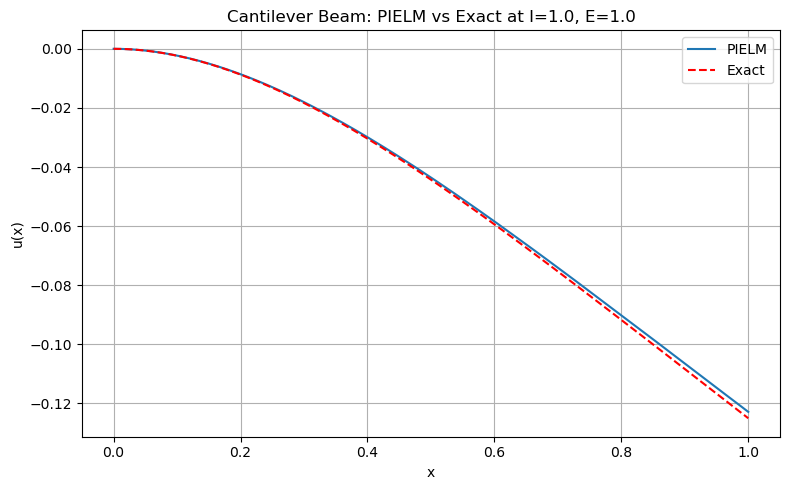

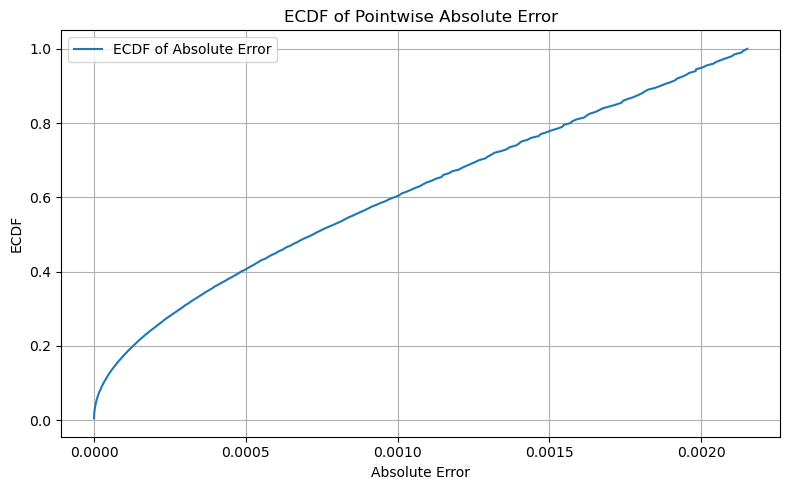

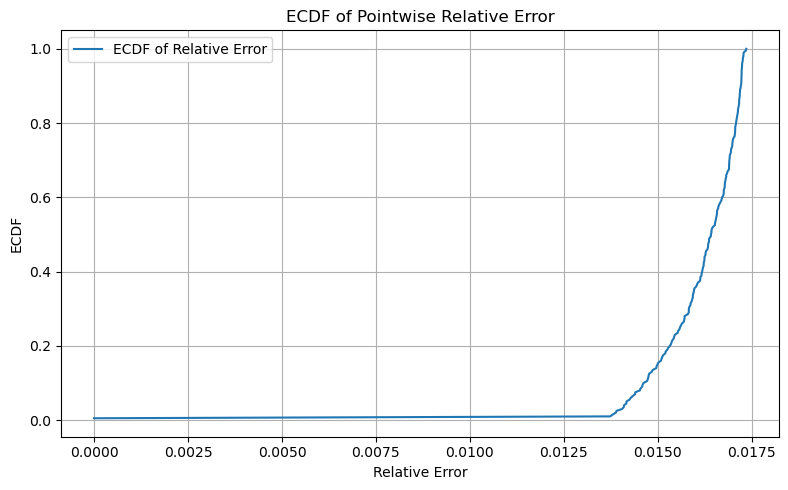

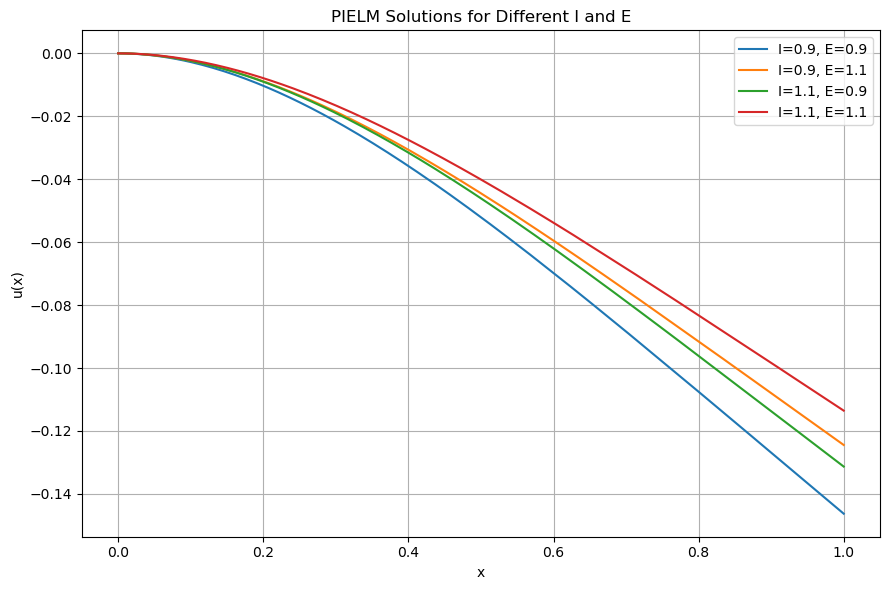

In [3]:
import torch
import torch.autograd as autograd
import numpy as np
import matplotlib.pyplot as plt
from itertools import product

torch.manual_seed(0)
torch.set_default_dtype(torch.float32)

# =========================================================
# Beam problem
# Governing equation:
#     E*I*u_xxxx = q
# Example: cantilever beam with uniform load q
# BCs:
#     u(0)=0, u'(0)=0, u''(L)=0, u'''(L)=0
# =========================================================

L = 1.0
q = -1.0

# Uncertain parameter ranges
I_range = [0.9, 1.1]
E_range = [0.9, 1.1]

# =========================================================
# Exact solution for cantilever beam under uniform load
# u(x) = q*x^2*(6L^2 - 4Lx + x^2)/(24EI)
# =========================================================
def exact_solution(x, I, E):
    return q * x**2 * (6*L**2 - 4*L*x + x**2) / (24 * E * I)

# =========================================================
# Full factorial sampling
# =========================================================
def full_factorial_sampling_3d(n1, n2, n3,
                               range1=(0.0, 1.0),
                               range2=(0.0, 1.0),
                               range3=(0.0, 1.0)):
    a1 = torch.linspace(range1[0], range1[1], n1)
    a2 = torch.linspace(range2[0], range2[1], n2)
    a3 = torch.linspace(range3[0], range3[1], n3)

    pts = list(product(a1, a2, a3))
    return torch.tensor(pts, dtype=torch.float32)

# =========================================================
# ELM setup
# Input = (x, I, E)
# =========================================================
hidden_size = 150
input_dim = 3

W = torch.randn(input_dim, hidden_size)
b = torch.randn(hidden_size)

def hidden_layer(X):
    # Gaussian activation
    return torch.exp(-(X @ W + b)**2)

# =========================================================
# Trial solution
# Use x^2 so that u(0)=0 and u'(0)=0 automatically
# =========================================================
def trial_features(X):
    x = X[:, 0:1]
    return (x**2) * hidden_layer(X)

# =========================================================
# Solve PIELM using full factorial PDE points
# =========================================================
def solve_pielm_full_factorial(
    n_x=10,
    n_I=10,
    n_E=10,
    n_bc_param=10,
    lambda_bc=50.0,
    reg=1e-6
):
    # -----------------------------------------------------
    # PDE collocation points: full factorial in (x, I, E)
    # -----------------------------------------------------
    X_pde = full_factorial_sampling_3d(
        n_x, n_I, n_E,
        range1=(0.0, L),
        range2=(I_range[0], I_range[1]),
        range3=(E_range[0], E_range[1])
    ).requires_grad_(True)

    U = trial_features(X_pde)

    A_cols = []
    for j in range(hidden_size):
        uj = U[:, j:j+1]

        grad1 = autograd.grad(uj.sum(), X_pde, create_graph=True)[0]
        uj_x = grad1[:, 0:1]

        grad2 = autograd.grad(uj_x.sum(), X_pde, create_graph=True)[0]
        uj_xx = grad2[:, 0:1]

        grad3 = autograd.grad(uj_xx.sum(), X_pde, create_graph=True)[0]
        uj_xxx = grad3[:, 0:1]

        grad4 = autograd.grad(uj_xxx.sum(), X_pde, create_graph=True)[0]
        uj_xxxx = grad4[:, 0:1]

        I_vals = X_pde[:, 1:2]
        E_vals = X_pde[:, 2:3]

        # PDE: E*I*u_xxxx = q
        A_cols.append(E_vals * I_vals * uj_xxxx)

    A = torch.hstack(A_cols)
    b_pde = torch.full((X_pde.shape[0], 1), q)

    # -----------------------------------------------------
    # Boundary conditions at x = L:
    # u''(L) = 0, u'''(L) = 0
    # Need parameter sampling only in (I,E)
    # -----------------------------------------------------
    IE_bc = full_factorial_sampling_3d(
        1, n_bc_param, n_bc_param,
        range1=(L, L),
        range2=(I_range[0], I_range[1]),
        range3=(E_range[0], E_range[1])
    ).requires_grad_(True)

    U_bc = trial_features(IE_bc)

    C1_cols = []   # u''(L)=0
    C2_cols = []   # u'''(L)=0

    for j in range(hidden_size):
        uj = U_bc[:, j:j+1]

        grad1 = autograd.grad(uj.sum(), IE_bc, create_graph=True)[0]
        uj_x = grad1[:, 0:1]

        grad2 = autograd.grad(uj_x.sum(), IE_bc, create_graph=True)[0]
        uj_xx = grad2[:, 0:1]

        grad3 = autograd.grad(uj_xx.sum(), IE_bc, create_graph=True)[0]
        uj_xxx = grad3[:, 0:1]

        C1_cols.append(uj_xx)
        C2_cols.append(uj_xxx)

    C1 = torch.hstack(C1_cols)
    C2 = torch.hstack(C2_cols)

    d1 = torch.zeros((IE_bc.shape[0], 1))
    d2 = torch.zeros((IE_bc.shape[0], 1))

    C = torch.vstack([C1, C2])
    d = torch.vstack([d1, d2])

    # -----------------------------------------------------
    # KKT system
    # -----------------------------------------------------
    A_T, C_T = A.T, C.T
    n_constraints = C.shape[0]

    KKT = torch.zeros(hidden_size + n_constraints,
                      hidden_size + n_constraints)

    KKT[:hidden_size, :hidden_size] = A_T @ A + reg * torch.eye(hidden_size)
    KKT[:hidden_size, hidden_size:] = lambda_bc * C_T
    KKT[hidden_size:, :hidden_size] = lambda_bc * C

    rhs = torch.vstack([A_T @ b_pde, lambda_bc * d])

    sol = torch.linalg.solve(KKT, rhs)
    beta = sol[:hidden_size]

    return beta, X_pde

# =========================================================
# Train
# =========================================================
beta, X_train = solve_pielm_full_factorial(
    n_x=10, n_I=10, n_E=10,
    n_bc_param=10,
    lambda_bc=50.0,
    reg=1e-6
)

print("Number of full-factorial PDE points:", X_train.shape[0])  # should be 1000

def predict(X):
    return trial_features(X) @ beta

# =========================================================
# Compare predicted and exact at selected values
# =========================================================
I_test = 1.0
E_test = 1.0

x_plot = torch.linspace(0, L, 200).reshape(-1, 1)
I_plot = torch.full_like(x_plot, I_test)
E_plot = torch.full_like(x_plot, E_test)

X_test = torch.cat([x_plot, I_plot, E_plot], dim=1)

u_pred = predict(X_test).detach().squeeze()
u_exact = exact_solution(x_plot, I_plot, E_plot).detach().squeeze()

rel_l2_error = torch.norm(u_pred - u_exact) / torch.norm(u_exact)
max_abs_error = torch.max(torch.abs(u_pred - u_exact))

print(f"Relative L2 error: {rel_l2_error.item():.6e}")
print(f"Max absolute error: {max_abs_error.item():.6e}")

# =========================================================
# ECDF Analysis
# =========================================================
abs_error = torch.abs(u_pred - u_exact)

eps = 1e-12
rel_error_pointwise = abs_error / (torch.abs(u_exact) + eps)

def compute_ecdf(data):
    data_sorted, _ = torch.sort(data)
    n = data_sorted.numel()
    ecdf = torch.arange(1, n + 1, dtype=torch.float32) / n
    return data_sorted, ecdf

# ECDF for absolute error
abs_err_sorted, abs_err_ecdf = compute_ecdf(abs_error)

# ECDF for relative error
rel_err_sorted, rel_err_ecdf = compute_ecdf(rel_error_pointwise)

print("\nECDF Summary for Absolute Error")
for t in [1e-6, 1e-5, 1e-4, 1e-3]:
    prob = (abs_error <= t).float().mean().item()
    print(f"P(|error| <= {t:.1e}) = {prob:.4f}")

print("\nECDF Summary for Relative Error")
for t in [1e-4, 1e-3, 1e-2, 1e-1]:
    prob = (rel_error_pointwise <= t).float().mean().item()
    print(f"P(relative error <= {t:.1e}) = {prob:.4f}")

# =========================================================
# Plot comparison
# =========================================================
plt.figure(figsize=(8, 5))
plt.plot(x_plot.numpy(), u_pred.numpy(), label="PIELM")
plt.plot(x_plot.numpy(), u_exact.numpy(), "r--", label="Exact")
plt.xlabel("x")
plt.ylabel("u(x)")
plt.title(f"Cantilever Beam: PIELM vs Exact at I={I_test}, E={E_test}")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# =========================================================
# Plot ECDF of Absolute Error
# =========================================================
plt.figure(figsize=(8, 5))
plt.plot(abs_err_sorted.numpy(), abs_err_ecdf.numpy(), label="ECDF of Absolute Error")
plt.xlabel("Absolute Error")
plt.ylabel("ECDF")
plt.title("ECDF of Pointwise Absolute Error")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# =========================================================
# Plot ECDF of Relative Error
# =========================================================
plt.figure(figsize=(8, 5))
plt.plot(rel_err_sorted.numpy(), rel_err_ecdf.numpy(), label="ECDF of Relative Error")
plt.xlabel("Relative Error")
plt.ylabel("ECDF")
plt.title("ECDF of Pointwise Relative Error")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# =========================================================
# Optional: compare displacement variation for different I,E
# =========================================================
cases = [
    (0.9, 0.9),
    (0.9, 1.1),
    (1.1, 0.9),
    (1.1, 1.1),
]

plt.figure(figsize=(9, 6))
for I_case, E_case in cases:
    I_case_vec = torch.full_like(x_plot, I_case)
    E_case_vec = torch.full_like(x_plot, E_case)
    X_case = torch.cat([x_plot, I_case_vec, E_case_vec], dim=1)
    u_case = predict(X_case).detach().squeeze()
    plt.plot(x_plot.numpy(), u_case.numpy(), label=f"I={I_case}, E={E_case}")

plt.xlabel("x")
plt.ylabel("u(x)")
plt.title("PIELM Solutions for Different I and E")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()